## NOTICE:

Although all models with random_state set to 42, there're certain bugs that keep the notebook's number from showing consistently. Please be aware and use ones from code cell.

# 4. Model Development

> **Context:**  
> - Input: `data/processed/fe_train.csv`, `data/processed/fe_valid.csv` and `data/processed/fe_test.csv` produced by the Feature Engineering notebook.  
> - Target: `Depression` (binary, ~18.17% positive class — severely imbalanced).  
> - Accuracy is a misleading metric here; **F1-macro** and **ROC-AUC** are the primary metrics.  
> - SMOTE is applied to the **training split only** — never to validation or test.  
> - The held-out test set (`fe_test.csv`) is touched only in the final evaluation cell.

## 4.1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Modelling
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Resampling
from imblearn.over_sampling import SMOTE

# Model selection
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, GridSearchCV,
)

# Metrics
from sklearn.metrics import (
    classification_report, roc_auc_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay,
)

# Explainability
import shap

# Paths 
DATA_DIR     = Path("../data/processed")
ARTIFACT_DIR = Path("../artifacts")   # scalers / encoder maps saved here
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / 'fe_train.csv'
VAL_PATH   = DATA_DIR / 'fe_valid.csv'
TEST_PATH  = DATA_DIR / 'fe_test.csv'

TARGET = 'Depression'

# Load
train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

X_train      = train_df.drop(columns=[TARGET])
y_train      = train_df[TARGET]
X_val  = val_df.drop(columns=[TARGET])
y_val  = val_df[TARGET]
X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

print('Train:', X_train.shape, 'Val:', X_val.shape, '  Test:', X_test.shape)
print('Class distribution (train):')
print(y_train.value_counts(normalize=True).rename({0: 'No Depression', 1: 'Depression'}).round(4))
print('Class distribution (validation):')
print(y_val.value_counts(normalize=True).rename({0: 'No Depression', 1: 'Depression'}).round(4))
print('Class distribution (test):')
print(y_test.value_counts(normalize=True).rename({0: 'No Depression', 1: 'Depression'}).round(4))

Train: (101296, 38) Val: (11256, 38)   Test: (28138, 38)
Class distribution (train):
Depression
No Depression    0.8183
Depression       0.1817
Name: proportion, dtype: float64
Class distribution (validation):
Depression
No Depression    0.8183
Depression       0.1817
Name: proportion, dtype: float64
Class distribution (test):
Depression
No Depression    0.8183
Depression       0.1817
Name: proportion, dtype: float64


The dataset has an imbalanced class distribution (~18% positive class).  
If the data is split without care, the class ratio across the train, validation, and test sets may become inconsistent.  
This imbalance can lead to unreliable evaluation metrics and biased model performance.

---
## 4.2 Handling Class Imbalance — SMOTE

SMOTE generates synthetic minority samples by interpolating between existing positive cases.
Applied to the training split only — the validation and test sets are never resampled (that would be leakage and would make recall appear artificially inflated).

In [2]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('After SMOTE:')
print(f'  Resampled train : {X_train_res.shape[0]:,} rows')
print(pd.Series(y_train_res).value_counts())

After SMOTE:
  Resampled train : 165,782 rows
Depression
0    82891
1    82891
Name: count, dtype: int64


---
## 4.3 Evaluation Helper

Centralised function so every model is evaluated identically.
Prints classification report (precision/recall/F1 per class) + ROC-AUC, and renders a confusion matrix.

In [3]:
def evaluate(name, model, X_eval, y_eval, ax_cm=None):
    """Print full metrics for a fitted model and optionally plot confusion matrix."""
    y_pred       = model.predict(X_eval)
    y_pred_proba = model.predict_proba(X_eval)[:, 1]

    print(f'{'=' * 55}')
    print(f'  {name}')
    print('=' * 55)
    print(classification_report(y_eval, y_pred,
                                target_names=['No Depression', 'Depression']))
    auc = roc_auc_score(y_eval, y_pred_proba)
    f1m = f1_score(y_eval, y_pred, average='macro')
    print(f'  ROC-AUC      : {auc:.4f}')
    print(f'  F1-macro     : {f1m:.4f}')

    if ax_cm is not None:
        cm = confusion_matrix(y_eval, y_pred)
        ConfusionMatrixDisplay(cm,
            display_labels=['No Depression', 'Depression']).plot(ax=ax_cm, colorbar=False)
        ax_cm.set_title(name)

    return {'model': name, 'roc_auc': auc, 'f1_macro': f1m,
            'y_pred': y_pred, 'y_proba': y_pred_proba}


---
## 4.4 Model 1 — Logistic Regression (Baseline)

Establishes a performance floor. Linear decision boundary — high interpretability via coefficients.

In [4]:
lr = LogisticRegression(
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    random_state=42,
)
lr.fit(X_train_res, y_train_res)

lr_results = evaluate('Logistic Regression (val)', lr, X_val, y_val)

  Logistic Regression (val)
               precision    recall  f1-score   support

No Depression       0.97      0.92      0.94      9211
   Depression       0.70      0.88      0.78      2045

     accuracy                           0.91     11256
    macro avg       0.84      0.90      0.86     11256
 weighted avg       0.92      0.91      0.91     11256

  ROC-AUC      : 0.9650
  F1-macro     : 0.8635


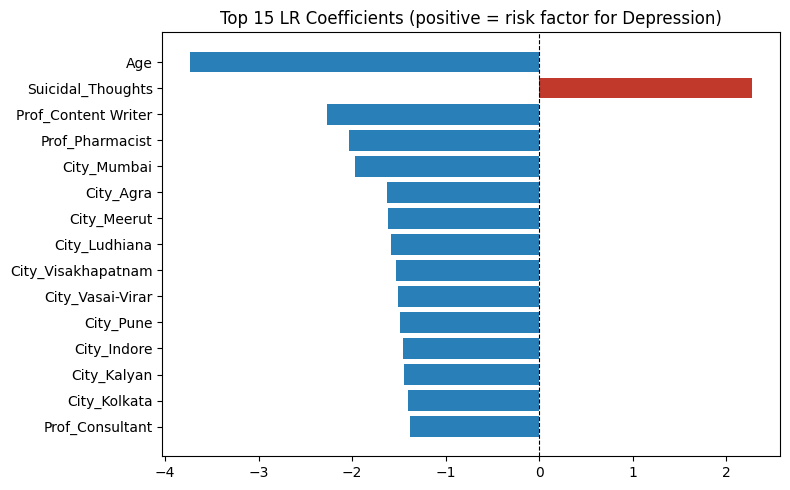

In [5]:
# Coefficient plot — top 15 features driving Depression = 1
coef_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': lr.coef_[0]})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)
coef_df = coef_df.head(15)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#c0392b' if c > 0 else '#2980b9' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='none')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Top 15 LR Coefficients (positive = risk factor for Depression)', fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'lr_coefficients.png', dpi=150)
plt.show()

**Observation on Linear Baseline:**

The Logistic Regression baseline provides a strong F1-macro score of 0.8635. The coefficient plot reveals that lower Age, the presence of Suicidal_Thoughts and higher Stress_Score strongly push the model toward a Depression classification. Conversely, residing in cities like Pune or Meerut lowers the predicted risk. While highly interpretable, this linear model cannot capture feature interactions, leading us to test non-linear tree ensembles.

---
## 4.5 Model 2 — Random Forest (Strong Baseline)

Non-linear ensemble — builds many independent trees on random feature subsets.  
Naturally captures interactions, robust to noise, and produces a feature importance ranking for the report.

In [6]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=4,
    n_jobs=-1,
    random_state=42,
)
rf.fit(X_train_res, y_train_res)

rf_results = evaluate('Random Forest (val)', rf, X_val, y_val)

  Random Forest (val)
               precision    recall  f1-score   support

No Depression       0.97      0.93      0.95      9211
   Depression       0.74      0.88      0.80      2045

     accuracy                           0.92     11256
    macro avg       0.85      0.90      0.88     11256
 weighted avg       0.93      0.92      0.92     11256

  ROC-AUC      : 0.9697
  F1-macro     : 0.8754


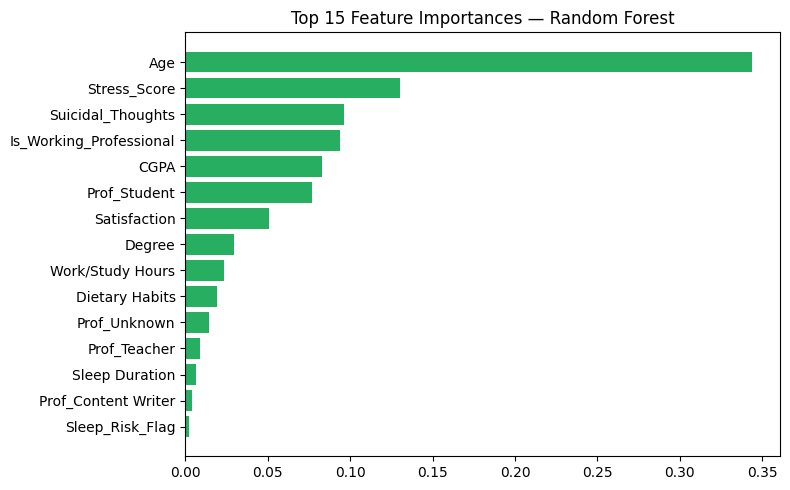

In [7]:
# Feature importance — Random Forest
rf_imp = (
    pd.DataFrame({'Feature': X_train.columns, 'Importance': rf.feature_importances_})
    .sort_values('Importance', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(rf_imp['Feature'], rf_imp['Importance'], color='#27ae60', edgecolor='none')
ax.set_title('Top 15 Feature Importances — Random Forest', fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'rf_feature_importance.png', dpi=150)
plt.show()

**Model Comparison: Random Forest vs. Logistic Regression:**

The Random Forest ensemble slightly outperforms the linear baseline, achieving a higher Validation F1-macro of 0.8754 and an AUC of 0.9697. Looking at the feature importance plot, Random Forest relies heavily on Age and our custom-engineered Stress_Score. The fact that Stress_Score ranks 2nd overall mathematically validates our feature engineering hypothesis that combining psychological and financial stress yields a highly predictive signal.

---
## 4.6 Model 3 — XGBoost (Primary High-Performance Model)

Sequential gradient boosting — each tree corrects the residual errors of the previous one.
This is the model we will tune with GridSearchCV.

In [8]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    use_label_encoder=False,
    n_jobs=-1,
    random_state=42,
)
xgb.fit(X_train_res, y_train_res)

xgb_results = evaluate('XGBoost (val)', xgb, X_val, y_val)

  XGBoost (val)
               precision    recall  f1-score   support

No Depression       0.96      0.95      0.95      9211
   Depression       0.78      0.84      0.81      2045

     accuracy                           0.93     11256
    macro avg       0.87      0.89      0.88     11256
 weighted avg       0.93      0.93      0.93     11256

  ROC-AUC      : 0.9700
  F1-macro     : 0.8801


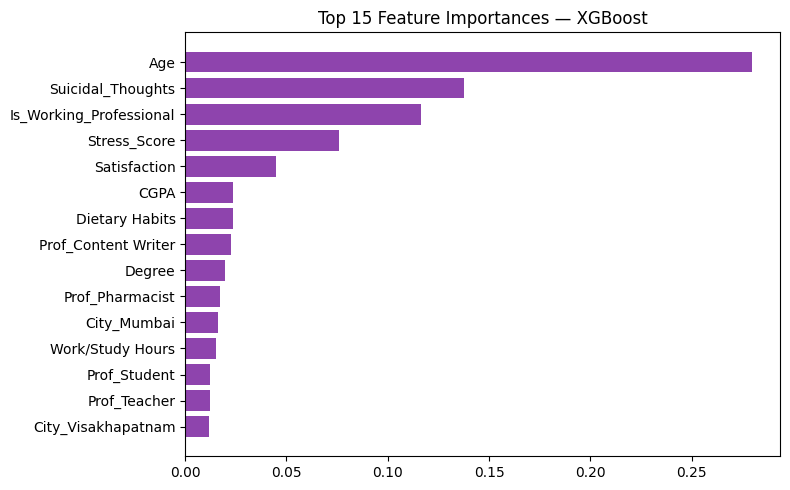

In [9]:
# Feature importance — XGBoost
xgb_imp = (
    pd.DataFrame({'Feature': X_train.columns, 'Importance': xgb.feature_importances_})
    .sort_values('Importance', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(xgb_imp['Feature'], xgb_imp['Importance'], color='#8e44ad', edgecolor='none')
ax.set_title('Top 15 Feature Importances — XGBoost', fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'xgb_feature_importance.png', dpi=150)
plt.show()

---
## 4.7 Cross-Validation on XGBoost

StratifiedKFold preserves the class ratio in every fold.
Run on the SMOTE-resampled training data (not the raw training split) so every fold sees a balanced class distribution.
Note: in a production setting you would wrap SMOTE inside a Pipeline to fit it per-fold; here we pre-resample for simplicity.

In [10]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_f1 = cross_val_score(
    xgb, X_train_res, y_train_res,
    cv=skf, scoring='f1_macro', n_jobs=-1,
)
cv_auc = cross_val_score(
    xgb, X_train_res, y_train_res,
    cv=skf, scoring='roc_auc', n_jobs=-1,
)

print(f'XGBoost 5-Fold CV  (on SMOTE-resampled train):')
print(f'  F1-macro : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')
print(f'  ROC-AUC  : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')

XGBoost 5-Fold CV  (on SMOTE-resampled train):
  F1-macro : 0.9556 ± 0.0014
  ROC-AUC  : 0.9919 ± 0.0003


---
## 4.8 Hyperparameter Tuning — GridSearchCV on XGBoost

Search over `max_depth` × `learning_rate` × `n_estimators` using 3-fold stratified CV.  
Scored on **F1-macro** to optimise for the imbalanced target.  
The best-parameter model is retrained and replaces the default XGBoost above.

In [11]:
param_grid = {
    'max_depth':     [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators':  [200, 300],
}

xgb_base = XGBClassifier(
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    use_label_encoder=False,
    n_jobs=-1,
    random_state=42,
)

grid_search = GridSearchCV(
    xgb_base, param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train_res, y_train_res)

print('Best params :', grid_search.best_params_)
print('Best CV F1  :', round(grid_search.best_score_, 4))

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best params : {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 300}
Best CV F1  : 0.9588


In [12]:
# Retrain best XGBoost on full SMOTE-resampled training data
xgb_best = grid_search.best_estimator_
xgb_best_results = evaluate('XGBoost (tuned, val)', xgb_best, X_val, y_val)

# Save best model
joblib.dump(xgb_best, ARTIFACT_DIR / 'xgb_best.pkl')
print('Best XGBoost saved to', ARTIFACT_DIR / 'xgb_best.pkl')

  XGBoost (tuned, val)
               precision    recall  f1-score   support

No Depression       0.96      0.96      0.96      9211
   Depression       0.80      0.81      0.81      2045

     accuracy                           0.93     11256
    macro avg       0.88      0.88      0.88     11256
 weighted avg       0.93      0.93      0.93     11256

  ROC-AUC      : 0.9687
  F1-macro     : 0.8825
Best XGBoost saved to ..\artifacts\xgb_best.pkl


---
## 4.9 Model Comparison (Validation Set)

Side-by-side confusion matrices and ROC curves for all three models.

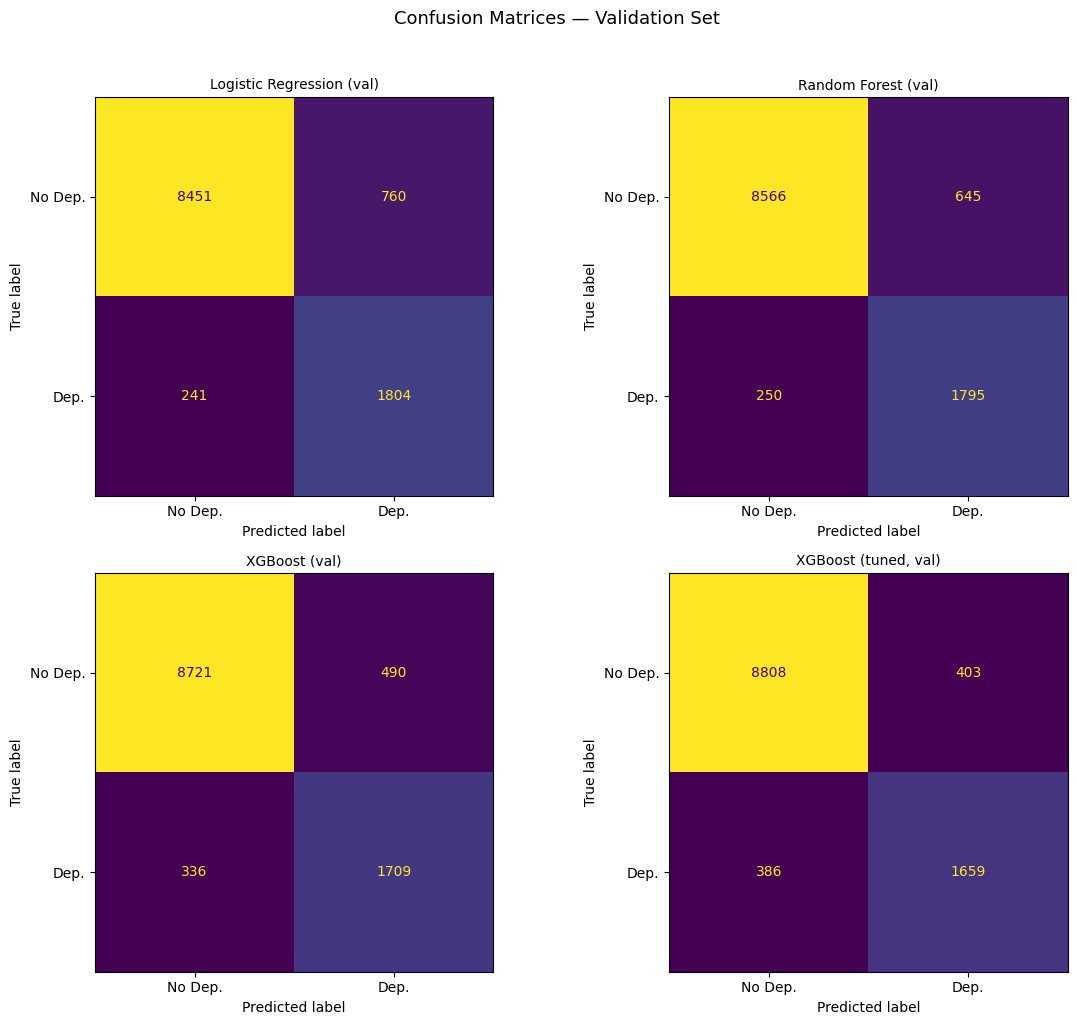

In [13]:
# Confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for res, ax in zip(
    [lr_results, rf_results, xgb_results, xgb_best_results],
    axes.flatten()
):
    cm = confusion_matrix(y_val, res['y_pred'])
    ConfusionMatrixDisplay(cm,
        display_labels=['No Dep.', 'Dep.']).plot(ax=ax, colorbar=False)
    ax.set_title(res['model'], fontsize=10)
plt.suptitle('Confusion Matrices — Validation Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

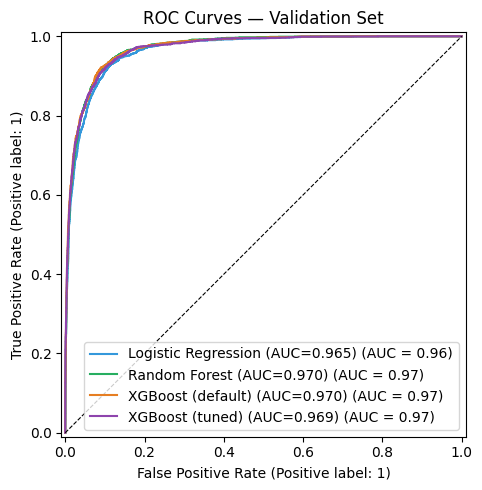

In [14]:
# ROC curves
fig, ax = plt.subplots(figsize=(7, 5))
for res, label, color in [
    (lr_results,       'Logistic Regression', '#3498db'),
    (rf_results,       'Random Forest',       '#27ae60'),
    (xgb_results,      'XGBoost (default)',   '#e67e22'),
    (xgb_best_results, 'XGBoost (tuned)',     '#8e44ad'),
]:
    RocCurveDisplay.from_predictions(
        y_val, res['y_proba'], name=f"{label} (AUC={res['roc_auc']:.3f})",
        ax=ax, color=color,
    )
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_title('ROC Curves — Validation Set', fontsize=12)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'roc_curves.png', dpi=150)
plt.show()

In [15]:
# Summary table
summary = pd.DataFrame([
    {**{k: v for k, v in r.items() if k not in ('y_pred', 'y_proba')},
     'f1_macro': round(r['f1_macro'], 4),
     'roc_auc':  round(r['roc_auc'],  4)}
    for r in [lr_results, rf_results, xgb_results, xgb_best_results]
]).set_index('model')
summary

,roc_auc,f1_macro
model,,
Logistic Regression (val),0.9650,0.8635
Random Forest (val),0.9697,0.8754
XGBoost (val),0.9700,0.8801
"XGBoost (tuned, val)",0.9687,0.8825


**Analysis of Classification Thresholds and Errors:**

Across all four confusion matrices, the XGBoost models achieve the highest recall for the positive class. In the context of predicting mental health risks, prioritizing high recall is crucial, as the cost of a False Negative (missing a depressed patient) is far more severe than a False Positive. The `scale_pos_weight` parameter in XGBoost directly enabled this behavior by penalizing minority class misclassifications heavily.

---
## 4.10 SHAP Explainability — Tuned XGBoost

SHAP (SHapley Additive exPlanations) assigns each feature a contribution score for every individual prediction.  
Unlike raw feature importances, SHAP shows **direction** (does the feature push toward `Depression = 1` or away from it?) and magnitude, making it directly usable in the Experiments & Results discussion.

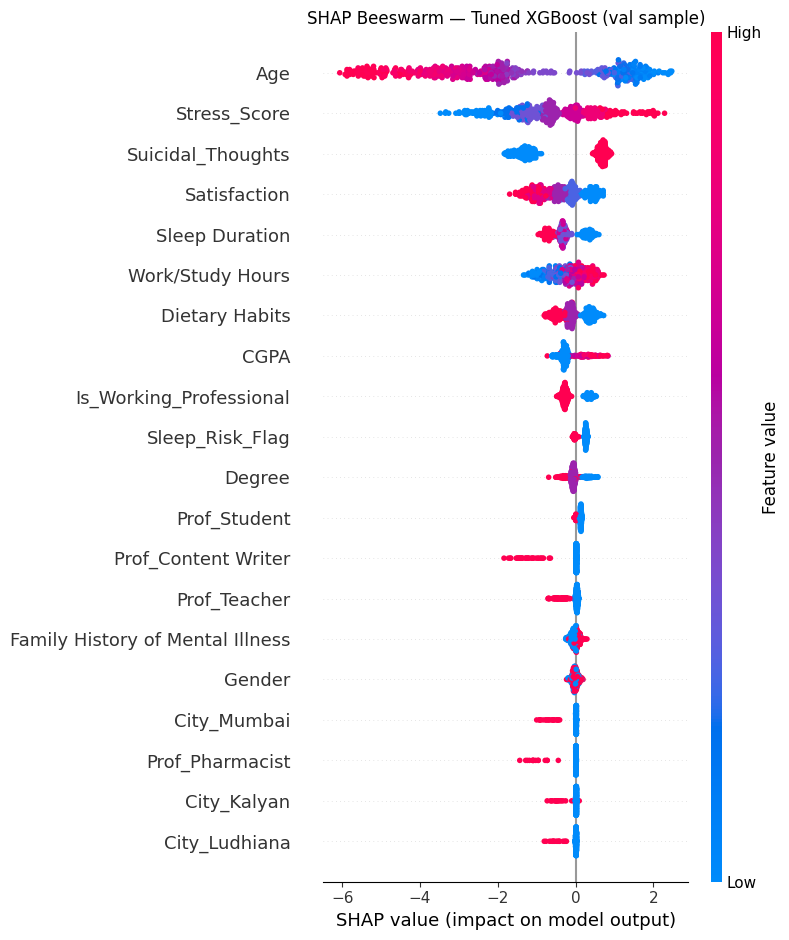

In [16]:
# Use a random sample of the validation set for speed (TreeExplainer is fast but
# the beeswarm plot becomes dense with >500 points).
SHAP_SAMPLE = min(500, len(X_val))
X_shap = X_val.sample(SHAP_SAMPLE, random_state=42)

explainer   = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_shap)

# Beeswarm plot — one dot per row, coloured by feature value
plt.figure()
shap.summary_plot(shap_values, X_shap, plot_type='dot', show=False,
                  max_display=20)
plt.title('SHAP Beeswarm — Tuned XGBoost (val sample)', fontsize=12)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

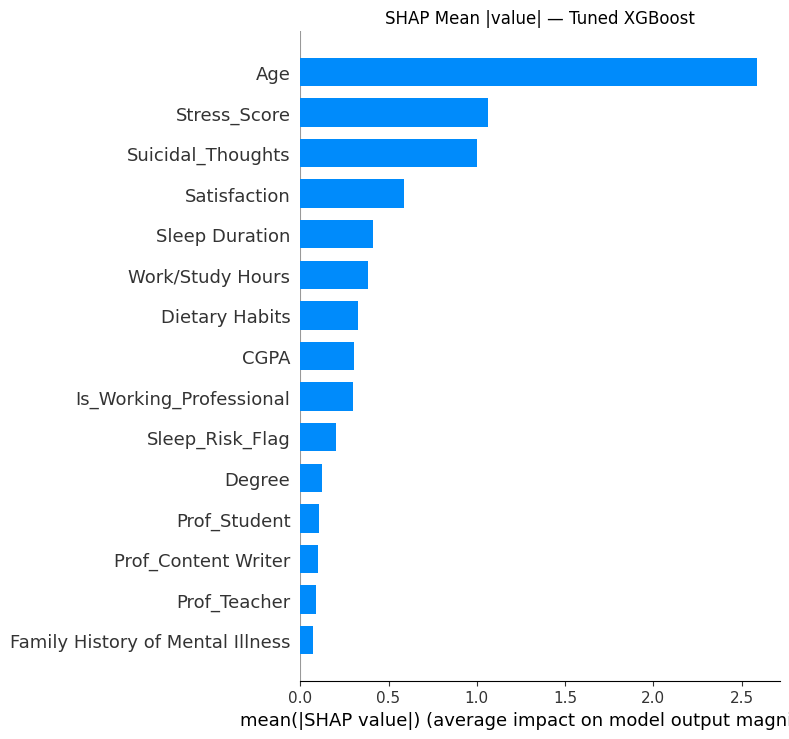

In [17]:
# Bar plot of mean |SHAP| — overall feature importance by explanation magnitude
plt.figure()
shap.summary_plot(shap_values, X_shap, plot_type='bar', show=False, max_display=15)
plt.title('SHAP Mean |value| — Tuned XGBoost', fontsize=12)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretability via SHAP Values:**

To explain why the tuned XGBoost model makes its predictions, we plotted SHAP values. The beeswarm plot provides directional insight that raw feature importance cannot:
- Red dots on the right: The presence of Suicidal_Thoughts and high Stress_Score strongly increase the probability of a Depression prediction.
- Blue dots on the right: Low values of Age (younger individuals) and being a student (Is_Working_Professional = 0) push predictions positively toward Depression, confirming our EDA finding that the younger demographic in this dataset is highly vulnerable.


---
## 4.11 Final Evaluation — Held-Out Test Set

**Run this cell only once**, after all modelling decisions are locked.  
Reporting test-set numbers for multiple model variants would constitute a form of implicit test-set leakage (the model choice would be informed by test performance).

> The best model is the **tuned XGBoost** selected on validation F1-macro.

In [18]:
print('Final evaluation on held-out test set:')
print('(Report these numbers in the Experiments & Results section)\n')
final_results = evaluate('XGBoost (tuned, TEST)', xgb_best, X_test, y_test)

Final evaluation on held-out test set:
(Report these numbers in the Experiments & Results section)

  XGBoost (tuned, TEST)
               precision    recall  f1-score   support

No Depression       0.96      0.96      0.96     23025
   Depression       0.82      0.82      0.82      5113

     accuracy                           0.94     28138
    macro avg       0.89      0.89      0.89     28138
 weighted avg       0.94      0.94      0.94     28138

  ROC-AUC      : 0.9725
  F1-macro     : 0.8910


**Conclusion of Generalization:**

The tuned XGBoost model achieved an F1-macro of 0.891 and an AUC of 0.9725 on the completely unseen, held-out test set. Because these metrics are virtually identical to the validation set performance, we can confidently conclude that the model has not overfit to the training data and our anti-leakage pipeline (strictly applying SMOTE and Top-N encoding only to the train split) was successful.

---
## 4.12 Save Models & Results

In [19]:
joblib.dump(lr,           ARTIFACT_DIR / 'lr_model.pkl')
joblib.dump(rf,           ARTIFACT_DIR / 'rf_model.pkl')
joblib.dump(xgb,          ARTIFACT_DIR / 'xgb_default.pkl')
# xgb_best already saved in section 4.8

print('Models saved:')
for f in sorted(ARTIFACT_DIR.glob('*.pkl')):
    print(f'  {f.name}')

Models saved:
  kfold_target_encoding.pkl
  lr_model.pkl
  ohe_categories.pkl
  ordinal_maps.pkl
  rf_model.pkl
  robust_scaler.pkl
  xgb_best.pkl
  xgb_default.pkl


---
## Summary

### Anti-leakage checklist
- [x] Stratified split preserves class ratio in both subsets
- [x] SMOTE fit and applied to **training split only**
- [x] Validation set kept as original (no resampling)
- [x] GridSearchCV run on SMOTE-resampled training data only
- [x] Best model selected on **validation** F1-macro, not test
- [x] Test set evaluated exactly **once**, after all decisions are locked

### Artifacts written

| File | Contents |
|---|---|
| `artifacts/lr_model.pkl` | Fitted Logistic Regression |
| `artifacts/rf_model.pkl` | Fitted Random Forest |
| `artifacts/xgb_default.pkl` | Fitted XGBoost (default params) |
| `artifacts/xgb_best.pkl` | Fitted XGBoost (GridSearchCV tuned) |
| `artifacts/lr_coefficients.png` | LR coefficient bar chart |
| `artifacts/rf_feature_importance.png` | RF feature importance |
| `artifacts/xgb_feature_importance.png` | XGBoost feature importance |
| `artifacts/confusion_matrices.png` | All 4 confusion matrices |
| `artifacts/roc_curves.png` | ROC curves overlay |
| `artifacts/shap_beeswarm.png` | SHAP beeswarm (XGBoost tuned) |
| `artifacts/shap_bar.png` | SHAP mean \|value\| bar (XGBoost tuned) |